In [1]:
# Install dependencies (run once in notebook)
!pip install pandas numpy scikit-learn matplotlib seaborn nltk spacy

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/14.2 MB 10.2 MB/s eta 0:00:02
   ---------- ----------------------------- 3.7/14.2 MB 9.7 MB/s eta 0:00:02
   -------------- ------------------------- 5.0/14.2 MB 8.3 MB/s eta 0:00:02
   ------------------- -------------------- 6.8/14.2 MB 8.2 MB/s eta 0:00:01
   ----------------------- ---------------- 8.4/14.2 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 10.5/14.2 MB 8.3 MB/s eta 0:00:01
   --------------------------------- ------ 12.1/14.2 MB 8.3 MB/s eta 0:00:01
   ------------------------------------ --- 12.8/14.2 MB 7.6 MB/s eta 0:00:01
   -------------------------------------- - 13.6/14.2 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 6.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/653.1 kB ? eta -:--:--
   ---------------------------------------- 653.1/653.1 kB 4.5 MB/s eta 0:00:00
   

In [8]:
# Load dataset (replace with your file path)
df = pd.read_csv(r"C:\Users\MEGHANA\OneDrive\Desktop\clickbait-detection\data\clickbait_data.csv")
df.head()



,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1


In [9]:
# Check for missing values
print(df.isnull().sum())
# Drop rows with missing values
df.dropna(inplace=True)


headline     0
clickbait    0
dtype: int64


In [15]:
# Define features and target variable
X = df["headline"]  # Assuming 'headline' is the text feature
y = df["clickbait"]  # Assuming 'is_clickbait' is the target variable
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
#text vectorization using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3127
           1       0.97      0.93      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



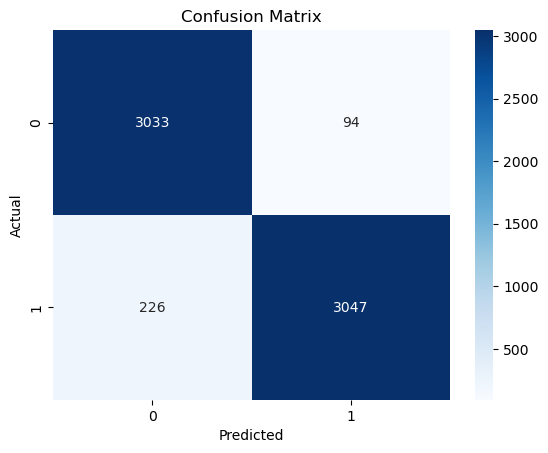

In [17]:
#train a logistic regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
#predict on test set
y_pred = model.predict(X_test_tfidf)
#evaluate model
print(classification_report(y_test, y_pred))
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [18]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3127
           1       0.90      0.95      0.92      3273

    accuracy                           0.92      6400
   macro avg       0.92      0.92      0.92      6400
weighted avg       0.92      0.92      0.92      6400



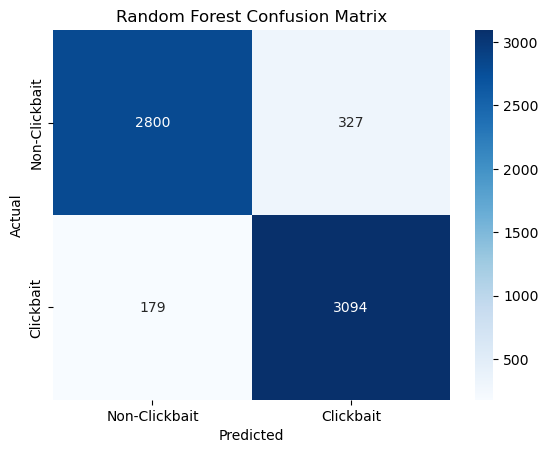

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_tfidf)

# Evaluation
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait','Clickbait'],
            yticklabels=['Non-Clickbait','Clickbait'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


SVM Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3127
           1       0.96      0.94      0.95      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



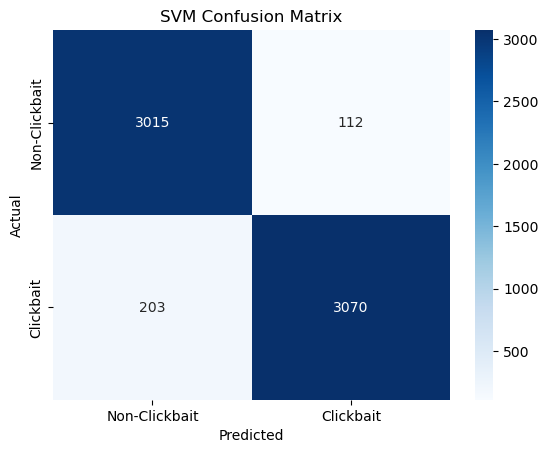

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train SVM model
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_tfidf)

# Evaluation
print("SVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait','Clickbait'],
            yticklabels=['Non-Clickbait','Clickbait'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


c:\Users\MEGHANA\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:56:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      3127
           1       0.95      0.80      0.87      3273

    accuracy                           0.88      6400
   macro avg       0.89      0.88      0.88      6400
weighted avg       0.89      0.88      0.88      6400



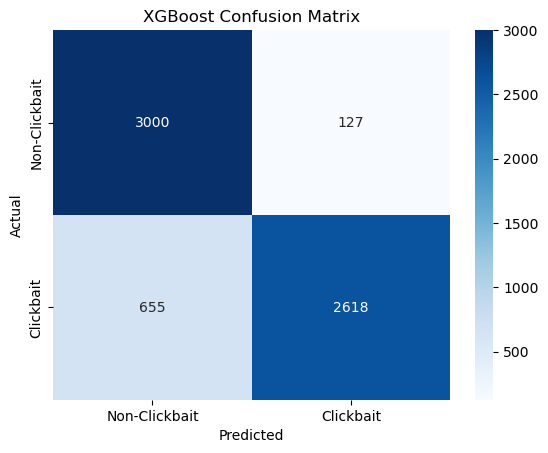

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test_tfidf)

# Evaluation
print("XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait','Clickbait'],
            yticklabels=['Non-Clickbait','Clickbait'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


Model Performance Comparison:



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.950000,0.950813,0.950000,0.950002
Random Forest,0.920937,0.921758,0.920937,0.920853
SVM,0.950781,0.951178,0.950781,0.950787
XGBoost,0.877812,0.888780,0.877812,0.877209


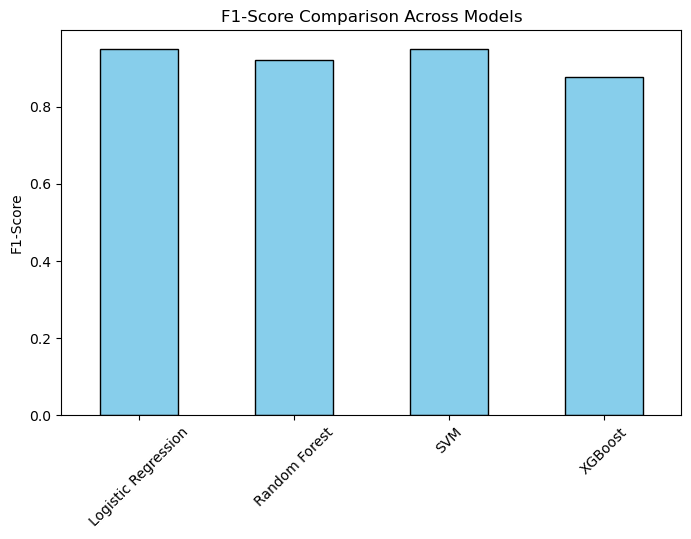

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect classification reports
reports = {
    "Logistic Regression": classification_report(y_test, y_pred, output_dict=True),
    "Random Forest": classification_report(y_test, rf_pred, output_dict=True),
    "SVM": classification_report(y_test, svm_pred, output_dict=True),
    "XGBoost": classification_report(y_test, xgb_pred, output_dict=True),
}

# Build comparison DataFrame
comparison = pd.DataFrame({
    model: {
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }
    for model, report in reports.items()
}).T

print("Model Performance Comparison:\n")
display(comparison)

# Plot F1-Score comparison
plt.figure(figsize=(8,5))
comparison["F1-Score"].plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("F1-Score Comparison Across Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.show()


In [31]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
print(classification_report(y_test, nb_pred))


              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3127
           1       0.96      0.95      0.96      3273

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)
knn_pred = knn_model.predict(X_test_tfidf)
print(classification_report(y_test, knn_pred))


              precision    recall  f1-score   support

           0       0.84      0.26      0.40      3127
           1       0.58      0.95      0.72      3273

    accuracy                           0.62      6400
   macro avg       0.71      0.61      0.56      6400
weighted avg       0.71      0.62      0.56      6400



In [33]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_tfidf, y_train)
gb_pred = gb_model.predict(X_test_tfidf)
print(classification_report(y_test, gb_pred))


              precision    recall  f1-score   support

           0       0.70      0.97      0.82      3127
           1       0.95      0.61      0.74      3273

    accuracy                           0.79      6400
   macro avg       0.83      0.79      0.78      6400
weighted avg       0.83      0.79      0.78      6400



Model Performance Comparison:



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.950000,0.950813,0.950000,0.950002
Random Forest,0.920937,0.921758,0.920937,0.920853
SVM,0.950781,0.951178,0.950781,0.950787
XGBoost,0.877812,0.888780,0.877812,0.877209
Naive Bayes,0.954375,0.954399,0.954375,0.954378
KNN,0.616406,0.706109,0.616406,0.563511
Gradient Boosting,0.785781,0.831184,0.785781,0.779339


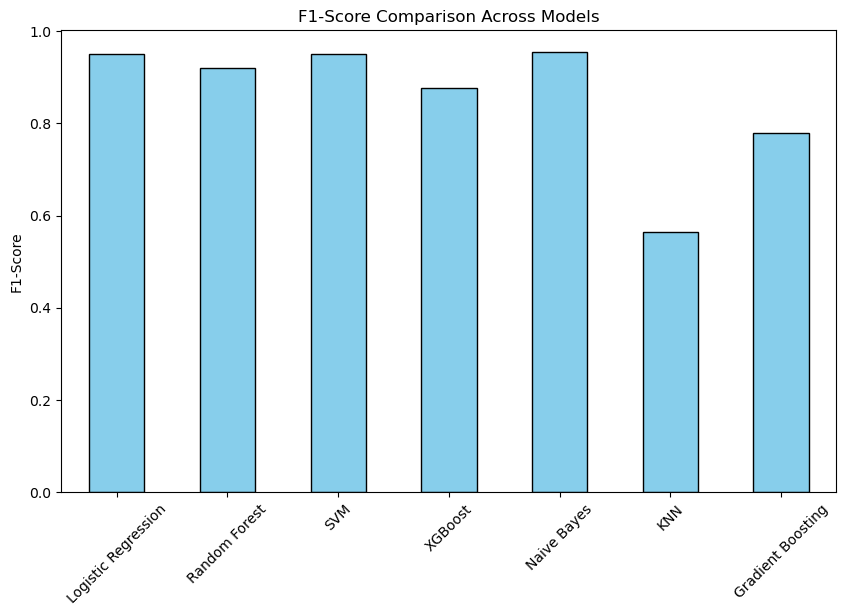

In [35]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Collect classification reports for all models
reports = {
    "Logistic Regression": classification_report(y_test, y_pred, output_dict=True),
    "Random Forest": classification_report(y_test, rf_pred, output_dict=True),
    "SVM": classification_report(y_test, svm_pred, output_dict=True),
    "XGBoost": classification_report(y_test, xgb_pred, output_dict=True),
    "Naive Bayes": classification_report(y_test, nb_pred, output_dict=True),
    "KNN": classification_report(y_test, knn_pred, output_dict=True),
    "Gradient Boosting": classification_report(y_test, gb_pred, output_dict=True),
}

# Build comparison DataFrame
comparison = pd.DataFrame({
    model: {
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }
    for model, report in reports.items()
}).T

print("Model Performance Comparison:\n")
display(comparison)

# Plot F1-Score comparison
plt.figure(figsize=(10,6))
comparison["F1-Score"].plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("F1-Score Comparison Across Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.show()


In [36]:
# Find the model with the highest F1-Score
best_model_name = comparison["F1-Score"].idxmax()
print("Best Model:", best_model_name)


Best Model: Naive Bayes


In [42]:
import joblib

# Dictionary of trained models
trained_models = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "XGBoost": xgb_model,
    "Naive Bayes": nb_model,
    "KNN": knn_model,
    "Gradient Boosting": gb_model,
}

# Select the best model object
best_model = trained_models[best_model_name]

# Save model and vectorizer
joblib.dump(best_model, "best_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("best_model.pkl and tfidf_vectorizer.pkl saved successfully!")


best_model.pkl and tfidf_vectorizer.pkl saved successfully!


In [40]:
# Load model and vectorizer
loaded_model = joblib.load("naive_bayes_model.pkl")  # replace with your best model file
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Example prediction
headline = ["You won’t believe what happened next!"]
X = loaded_vectorizer.transform(headline)
prediction = loaded_model.predict(X)
print("Prediction:", "Clickbait" if prediction[0] == 1 else "Not Clickbait")


Prediction: Clickbait
